# In-context learning, from zero

A learning notebook: build up in-context learning piece by piece, watching each idea land before adding the next.

In [1]:
import torch
import numpy as np

torch.manual_seed(42)
print("Torch device:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))

Torch device: cuda


## Dataset — matching the paper, not TinyStories

Olsson et al. 2022 trained their small models on an earlier version of the corpus described in
Askell et al. 2021 (arXiv:2112.00861): **filtered Common Crawl + internet books + ~10% Python
code**, plus several smaller distributions. Askell et al.'s exact corpus was never released.

We use `monology/pile-uncopyrighted` instead: The Pile with the five subsets under copyright
takedown removed (Books3, BookCorpus2, OpenSubtitles, YTSubtitles, OWT2). What remains — Pile-CC
(filtered Common Crawl), Gutenberg (books), GitHub (code, ~7-8% of tokens in the original Pile mix
— close to the paper's ~10%), plus the same long tail of smaller distributions Askell et al.
describe — is the closest reliably-downloadable public match. It's also what Pythia, this
project's other reference model family, was trained on.

**Why this matters for what we're building:** the earlier `stage2c_induction_tinystories.ipynb`
notebook, trained on TinyStories, never reproduced the paper's sharp induction-score phase
transition — the rise was gradual instead. TinyStories has no code and only short documents;
code's near-verbatim repetition may be exactly what sharpens that signal in the paper. Training on
a Pile-like mix lets us actually test that, instead of assuming it.

In [2]:
DATASET_NAME = "monology/pile-uncopyrighted"  # near-identical to Olsson et al.'s corpus
CHAR_BUDGET = 200_000_000  # same order of magnitude as the stage2c TinyStories run
CACHE_DIR = "checkpoints/icl_pile"
CORPUS_CACHE = f"{CACHE_DIR}/corpus.txt"

VOCAB_SIZE = 2048  # our own byte-level BPE; chosen by a fertility sweep (see below)
TOKENIZER_CACHE = f"{CACHE_DIR}/tokenizer.json"
TOKENS_CACHE = f"{CACHE_DIR}/tokens_v{VOCAB_SIZE}.npy"

print(
    f"[config] dataset={DATASET_NAME!r} char_budget={CHAR_BUDGET:,} cache={CORPUS_CACHE!r}\n"
    f"[config] vocab_size={VOCAB_SIZE:,} tokenizer={TOKENIZER_CACHE!r} tokens={TOKENS_CACHE!r}"
)

[config] dataset='monology/pile-uncopyrighted' char_budget=200,000,000 cache='checkpoints/icl_pile/corpus.txt'
[config] vocab_size=2,048 tokenizer='checkpoints/icl_pile/tokenizer.json' tokens='checkpoints/icl_pile/tokens_v2048.npy'


## Smoke test — does this actually stream, and is it what we expect?

Before pulling `CHAR_BUDGET` characters, pull just 5 rows and look at them. Each row is
`{"text": ..., "meta": {"pile_set_name": ...}}` — `pile_set_name` tells us which of the Pile's
original components a row came from, so we can sanity-check the mix (Common Crawl, code, books,
...) before committing to a full pull.

In [3]:
from datasets import load_dataset

_stream = load_dataset(DATASET_NAME, split="train", streaming=True)
_sample = [row for _, row in zip(range(5), _stream)]

for i, row in enumerate(_sample):
    source = row["meta"]["pile_set_name"]
    preview = row["text"][:100].replace("\n", " ")
    print(f"[{i}] source={source!r}")
    print(f"    {preview!r}")

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

[0] source='Pile-CC'
    'It is done, and submitted. You can play “Survival of the Tastiest” on Android, and on the web. Playi'
[1] source='Github'
    '<?xml version="1.0" encoding="UTF-8"?>\r <segment>\r     <name>PD1</name>\r     <description>Patient Ad'
[2] source='Pile-CC'
    'Topic: reinvent midnight madness  Amazon announced a new service at the AWS re:Invent Midnight Madne'
[3] source='Pile-CC'
    'About Grand Slam Fishing Charters  As a family owned business we know how important it is that your '
[4] source='StackExchange'
    "Q:  Why was Mundungus banned from the Hog's Head?  In Order of the Phoenix while the trio were in th"


## Model architecture

Two-layer, attention-only is the tractable case Olsson et al. can write the exact circuit for —
but the paper's own text only commits to that qualitative shape ("2-layer attention-only");
Anthropic never released the actual weights. Several community-trained models fill that gap in
`transformer_lens`, and their configs are **not interchangeable**, so it's worth being precise
about which one we mean:

- `transformer_lens`'s `attn-only-2l` alias resolves to `NeelNanda/Attn_Only_2L512W_C4_Code`:
  `d_model=512`, standard positional embeddings, trained on C4+Code.
- `ArthurConmy/redwood_attn_2l` is a separate, smaller model: `d_model=256`, shortformer
  positional embeddings, `d_vocab=50259`.

We adopt **`redwood_attn_2l`'s architecture numbers** below (verified against its real
`config.json` on HuggingFace, not from memory) as **our own training config** — training this
architecture from scratch on the Pile-uncopyrighted corpus configured above, not loading
`redwood_attn_2l`'s pretrained weights.

`d_vocab` is the one number we deliberately *don't* borrow from `redwood_attn_2l`: it's a
property of its tokenizer, not the architecture, and that tokenizer was fit to whatever corpus
Arthur Conmy trained on — not ours. Dataset preparation (below) trains our own byte-level BPE
tokenizer on the Pile-uncopyrighted corpus instead, sized to `VOCAB_SIZE` — small enough that the
embedding/unembedding matrices stay proportionate to this model's width (`d_model=256`) rather
than dwarfing it the way a 50k-vocab GPT-2 tokenizer would.

| Setting | Value | Note |
|---|---|---|
| `n_layers` | 2 | |
| `d_model` | 256 | |
| `n_heads` | 8 | |
| `d_head` | 32 | = d_model / n_heads |
| `n_ctx` | 2048 | context length |
| `d_vocab` | `VOCAB_SIZE` (2048) | our own tokenizer, not redwood's — see above |
| `attn_only` | `True` | no MLP blocks — layers compose purely through attention |
| `normalization_type` | `"LN"` | standard LayerNorm |
| `positional_embedding_type` | `"shortformer"` | positional info injected into Q/K, not added to the residual stream at layer 0 |
| Tokenizer | byte-level BPE | trained fresh on our corpus in dataset preparation, GPT-2's algorithm not its vocabulary |

**Why this architecture matters for induction:** exactly 2 layers forces layer-0 heads into the
"previous-token head" role (there's nothing earlier to compose from) and layer-1 heads into the
"induction head" role via K-composition — the same depth argument the paper itself makes for why
one layer can't do this.

In [4]:
MODEL_CONFIG = dict(
    n_layers=2,
    d_model=256,
    n_heads=8,
    d_head=32,
    n_ctx=2048,
    d_vocab=VOCAB_SIZE,  # our own tokenizer (dataset prep below), not redwood_attn_2l's 50259
    attn_only=True,
    normalization_type="LN",
    positional_embedding_type="shortformer",
)

n_params_estimate = 4 * MODEL_CONFIG["d_model"] ** 2 * MODEL_CONFIG["n_layers"]  # attn-only, QKVO per layer
embed_params_estimate = 2 * MODEL_CONFIG["d_model"] * MODEL_CONFIG["d_vocab"]  # embed + unembed
print(f"[model config] {MODEL_CONFIG}")
print(f"[model config] rough attn-param estimate: {n_params_estimate:,} (excludes embed/unembed)")
print(f"[model config] rough embed+unembed estimate: {embed_params_estimate:,}")

[model config] {'n_layers': 2, 'd_model': 256, 'n_heads': 8, 'd_head': 32, 'n_ctx': 2048, 'd_vocab': 2048, 'attn_only': True, 'normalization_type': 'LN', 'positional_embedding_type': 'shortformer'}
[model config] rough attn-param estimate: 524,288 (excludes embed/unembed)
[model config] rough embed+unembed estimate: 1,048,576


## Dataset preparation

Five steps, each its own cell so we can check the output before moving on:

1. **Stream and cache the raw corpus** — pull `CHAR_BUDGET` characters from `DATASET_NAME` (same
   schema the smoke test confirmed: `{"text": ..., "meta": {"pile_set_name": ...}}`), concatenate,
   write to `CORPUS_CACHE` so a re-run doesn't re-download.
2. **Train our own byte-level BPE tokenizer** — GPT-2's algorithm (`ByteLevel` pre-tokenizer +
   decoder, so code/punctuation/non-English text never hits an unknown token), fit to *this*
   corpus rather than reused from `redwood_attn_2l`'s tokenizer, at `VOCAB_SIZE` (2048) — sized
   for this model's width, not GPT-2's own 50257. Cached to `TOKENIZER_CACHE`.
3. **Tokenize and cache token ids** — encode the cached text with our tokenizer, save the id array
   to `TOKENS_CACHE`. Tokenizing 200M characters is slow enough to be worth caching once, not
   redoing per notebook run.
4. **Hold out a fixed evaluation slice** — set aside a chunk of tokens never used for training.
   `stage2c_induction_tinystories.ipynb` found that a fixed held-out batch gives a much
   lower-variance loss reading than sampling fresh minibatches — worth having in place before we
   train, not bolted on after.
5. **Chunk into training sequences** — split the remaining tokens into fixed-length windows of
   `MODEL_CONFIG["n_ctx"]` (2048) for batching.

Each step prints enough to sanity-check itself (corpus size, tokens-per-char, sequence count)
before we commit to the next one.

In [5]:
# Step 1 — stream + cache the raw corpus
import os
from collections import Counter

os.makedirs(CACHE_DIR, exist_ok=True)

if os.path.exists(CORPUS_CACHE):
    with open(CORPUS_CACHE, encoding="utf-8") as f:
        corpus = f.read()
    print(f"[corpus] cache hit: {len(corpus):,} chars from {CORPUS_CACHE}")
else:
    from datasets import load_dataset

    stream = load_dataset(DATASET_NAME, split="train", streaming=True)
    parts, total, mix = [], 0, Counter()
    for row in stream:
        parts.append(row["text"])
        mix[row["meta"]["pile_set_name"]] += len(row["text"])
        total += len(row["text"]) + 1
        if total >= CHAR_BUDGET:
            break
    corpus = "\n".join(parts)
    with open(CORPUS_CACHE, "w", encoding="utf-8") as f:
        f.write(corpus)
    print(f"[corpus] streamed + cached {len(corpus):,} chars -> {CORPUS_CACHE}")
    print("[corpus] source mix (share of chars):")
    for name, chars in mix.most_common():
        print(f"    {name:>16}: {chars / total:6.1%}")

[corpus] cache hit: 200,213,166 chars from checkpoints/icl_pile/corpus.txt


In [6]:
# Step 2 — train our own byte-level BPE tokenizer on this corpus
from tokenizers import Tokenizer, decoders, models, pre_tokenizers, trainers

if os.path.exists(TOKENIZER_CACHE):
    tokenizer = Tokenizer.from_file(TOKENIZER_CACHE)
    print(f"[tok] cache hit: {tokenizer.get_vocab_size()} tokens from {TOKENIZER_CACHE}")
else:
    tokenizer = Tokenizer(models.BPE())
    tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=True)
    tokenizer.decoder = decoders.ByteLevel()
    trainer = trainers.BpeTrainer(
        vocab_size=VOCAB_SIZE,
        special_tokens=["<|endoftext|>"],
        initial_alphabet=pre_tokenizers.ByteLevel.alphabet(),  # every byte, so no [UNK] ever
    )
    chunk = 1_000_000
    tokenizer.train_from_iterator(
        (corpus[i : i + chunk] for i in range(0, len(corpus), chunk)), trainer=trainer
    )
    tokenizer.save(TOKENIZER_CACHE)
    print(f"[tok] trained {tokenizer.get_vocab_size()} tokens -> {TOKENIZER_CACHE}")

# Log a few tokenisations (CLAUDE.md: always show how the tokenizer splits representative text).
# 'Ġ' marks a leading space in byte-level BPE. Note how the repeated word reuses the same token id —
# that token-level repetition is exactly what an induction head keys on.
for s in ["The cat sat on the mat.", "def induction_head(x):", " Lily Lily Lily"]:
    enc = tokenizer.encode(s)
    print(f"  {s!r} -> {len(enc.ids)} tokens: {enc.tokens}")

[tok] cache hit: 2048 tokens from checkpoints/icl_pile/tokenizer.json
  'The cat sat on the mat.' -> 9 tokens: ['ĠThe', 'Ġc', 'at', 'Ġs', 'at', 'Ġon', 'Ġthe', 'Ġmat', '.']
  'def induction_head(x):' -> 11 tokens: ['Ġdef', 'Ġin', 'du', 'ction', '_', 'he', 'ad', '(', 'x', ')', ':']
  ' Lily Lily Lily' -> 6 tokens: ['ĠL', 'ily', 'ĠL', 'ily', 'ĠL', 'ily']


In [7]:
# Step 3 — tokenize the whole corpus once and cache the ids
import numpy as np

if os.path.exists(TOKENS_CACHE):
    tokens = np.load(TOKENS_CACHE)
    print(f"[tok] token cache hit: {len(tokens):,} ids from {TOKENS_CACHE}")
else:
    step = 5_000_000  # encode in chunks so we never hold one giant Encoding in memory
    chunks = [
        np.asarray(tokenizer.encode(corpus[i : i + step]).ids, dtype=np.uint16)
        for i in range(0, len(corpus), step)
    ]
    tokens = np.concatenate(chunks)
    np.save(TOKENS_CACHE, tokens)
    print(f"[tok] encoded {len(tokens):,} tokens -> {TOKENS_CACHE}")

print(f"[tok] {len(tokens) / len(corpus):.4f} tokens/char on the full corpus")

[tok] token cache hit: 78,406,260 ids from checkpoints/icl_pile/tokens_v2048.npy
[tok] 0.3916 tokens/char on the full corpus


In [8]:
# Step 4 — hold out a fixed evaluation slice (deterministic tail, never trained on)
n_ctx = MODEL_CONFIG["n_ctx"]
EVAL_TOKENS = 100 * n_ctx  # ~100 held-out sequences; a fixed slice gives a low-variance eval loss

train_tokens = tokens[:-EVAL_TOKENS]
eval_tokens = tokens[-EVAL_TOKENS:]
print(f"[split] train {len(train_tokens):,} tokens | eval {len(eval_tokens):,} tokens (fixed tail)")

[split] train 78,201,460 tokens | eval 204,800 tokens (fixed tail)


In [9]:
# Step 5 — chunk each split into fixed-length n_ctx windows for batching
def chunk_sequences(ids, seq_len):
    usable = (len(ids) // seq_len) * seq_len  # drop the ragged remainder
    return ids[:usable].reshape(-1, seq_len)


train_seqs = chunk_sequences(train_tokens, n_ctx)
eval_seqs = chunk_sequences(eval_tokens, n_ctx)
print(f"[chunk] train {train_seqs.shape} | eval {eval_seqs.shape} (seq_len={n_ctx})")

[chunk] train (38184, 2048) | eval (100, 2048) (seq_len=2048)


## Training

Trained in-notebook, not via an offline script — consistent with this notebook's own approach so
far (dataset streaming, tokenizer training, and chunking all happened in-cell, not in a separate
`train_*.py`). The training cell below is checkpoint-cached the same way the corpus/tokenizer cells
already are above it: it loads `model.pt` and skips straight to it if a checkpoint already covers
the requested `TOKEN_BUDGET`, so re-running this notebook after a real pass stays fast.

Three cells, in order:

1. **Build the model** — `tiny.make_tiny_model(**MODEL_CONFIG)`, a thin wrapper around
   `transformer_lens.HookedTransformer` shared with the `stage2c`/`stage2dash2` notebooks.
2. **Calibrate** — a short trial run (~30 steps) to measure tokens/sec and pick a batch size before
   committing to the full run. `n_ctx=2048` here is 4x `stage2c`'s 512, so attention memory is
   roughly 16x costlier per sequence — worth measuring, not guessing.
3. **Train** — AdamW + warmup/cosine decay, same recipe as `train_stage2c.py`, targeting a
   400M-token budget (this corpus has 78.2M train tokens, so that's ~5.1 epochs of reuse). Logs,
   every 100 steps on the fixed held-out eval batch: scalar training loss, scalar eval loss, the
   **full per-position loss vector** (`loss_per_token=True`, averaged over the eval batch), and an
   induction score (`tiny.induction_scores`). The per-position vector is the one new capture this
   sub-project adds — it's what later panels use for the ICL score (loss at token 500 minus loss
   at token 50) and the loss-by-context-index curve, so it's logged now rather than requiring a
   retrain later. **Resumable:** raising `TOKEN_BUDGET` and re-running continues training from the
   existing checkpoint's weights, optimizer state, and RNG stream on the same warmup/cosine
   schedule (now computed over the new, larger step count), rather than restarting from scratch.
   Progress also goes to a plain log file (`train_log.txt`) that `tail -f` can follow live — a
   notebook only gets a cell's `print()` output written to disk once the whole run finishes, so
   printing alone isn't watchable mid-run. Numbered snapshots (every 200 steps, under `snapshots/`)
   sit alongside the single "latest" checkpoint, so a run that goes wrong partway through can be
   rolled back to an earlier point instead of only ever resuming from the most recent state.

**No pass/fail gate.** `train_stage2c.py` refuses to save its checkpoint if the induction score
misses a threshold. Here the entire point is testing whether Olsson et al.'s phase transition shows
up on this Pile-like corpus — a hard gate would make a negative result unobservable, and the
`stage2c` notebook's own Panel 0 already found value in reporting a negative result honestly. So:
always save, and report whatever the score turns out to be.

**Two different metrics, not to be confused.** `tiny.induction_scores` (logged below as
`induction=...`) is an *attention*-based diagnostic: prefix-matching strength on synthetic
repeated-random-token sequences, bounded in `[0, 1]`, calibrated against this repo's own past runs
(`stage2c`'s 0.2 gate, `stage2dash2`'s 0.4 gate on a different corpus). It is **not** Olsson et
al.'s actual in-context-learning (ICL) score, which is a *loss* difference — loss at token 500
minus loss at token 50 in context — typically negative, around -0.1 at baseline and dropping to
about -0.4 once induction forms. The two disagree here.

**First pass (150M tokens, 52.5 min):** eval loss converged well (8.05 → 3.32). The attention-based
induction score sat completely flat at 0.016 the entire run. `train_stage2c.py`'s own probes found
the `shortformer` positional embedding (this notebook's choice, matching `redwood_attn_2l`'s real
config) forms induction far slower than standard positions — 0.022 at 130M tokens vs. 0.096 for a
standard-position architecture on half the data — so the budget was raised to 400M tokens (~5.1
epochs) to give it more room. The 150M-token run's checkpoint and metrics are kept at
`checkpoints/icl_pile/runs/*_150M_tokens.*` for comparison. (That first run predates the resume
support above, so extending it started a fresh 400M-token run rather than continuing its weights —
any budget increase from here on continues in place instead.)

**Second pass (400M tokens, 140.1 min):** eval loss kept improving — 8.05 → 2.87, well past the
150M-token run's 3.32 — no plateau. The attention-based induction score again stayed flat, this
time in a 0.014–0.019 band the entire run, ending at 0.015.

The actual ICL score, computed naively as a single-position difference
(`per_position_loss[step][499] - per_position_loss[step][49]`), is too noisy to trust on its own:
per-sequence variance across the 100-sequence eval set is enormous (std ≈ 3.3 nats vs. a mean of
only ≈ -0.06 at the final checkpoint — indistinguishable from zero, t ≈ -0.18). Averaging a ±25
window around each anchor instead of one exact token cancels most of that per-token noise (a single
position's loss is dominated by *which specific word* happens to sit there in each of the 100
sequences, not by how much context precedes it). With that fix, the signal becomes real and
statistically solid (t ≈ -2.7 at the final checkpoint): the window-averaged ICL score rises from
about 0 to roughly **-0.35 to -0.37** within the first ~300-500 steps, then holds there (even
deepening slightly) for the rest of training — a genuine, sustained transition, not the noise
artifact an earlier pass at this markdown mistakenly reported as a "spike that decays." The 150M-
token run shows the same shape, settling near -0.37 by its end too. That final magnitude sits right
in the paper's own reported range for "induction formed."

One more check the paper leans on for causality: a bump or kink in the loss curve **coincident**
with the ICL-score transition. There isn't one here — `eval_loss` decreases smoothly and
monotonically the entire run (8.05 → 5.45 → 4.19 → 3.91 → ...), with no anomaly anywhere near steps
100-500 where the ICL score does all its transitioning. (The same absence shows up in
`stage2c_induction_tinystories.ipynb`'s Panel 0, on a completely different corpus and metric.)

So: a real, sustained, paper-magnitude ICL-score transition **is** present — but neither the
attention-based induction proxy nor a loss-curve anomaly supports it being the paper's specific
"discrete circuit switches on" story. Whatever mechanism produces this looks more like a smooth
capability improvement than a sudden phase change. Loss-by-context-index and its derivative (below)
are where this gets pinned down further.

In [10]:
# Build the model — tiny.py is shared with the stage2c/stage2dash2 notebooks
import sys

sys.path.insert(0, "/home/yassermakram/code/fanous-llm-lens/notebooks/education")
import tiny

# tiny.make_tiny_model derives d_head itself (d_model // n_heads); MODEL_CONFIG's own
# d_head entry is documentation for the table above, not one of its kwargs.
model_kwargs = {k: v for k, v in MODEL_CONFIG.items() if k != "d_head"}

device = tiny.device()
model = tiny.make_tiny_model(**model_kwargs)
n_params = sum(p.numel() for p in model.parameters())
print(f"[model] device={device}")
print(f"[model] params: {n_params:,}")

[model] device=cuda
[model] params: 2,102,784


/home/yassermakram/code/fanous-llm-lens/notebooks/education/tiny.py:25: UserWarning: expandable_segments not supported on this platform (Triggered internally at ../c10/hip/HIPAllocatorConfig.h:29.)
  torch.ones(1, device="cuda").add_(1)


In [11]:
# Calibrate — measure tokens/sec at a candidate batch size before committing to the full run.
# Runs on a throwaway model copy (same seed, discarded after) so these steps don't pre-train the
# real `model` above. 100GB+ unified memory is available on this iGPU, so we don't need to be
# conservative here — n_ctx=2048 is the real memory driver (4x stage2c's 512, ~16x costlier
# attention per sequence), not batch size. Tried: batch=128 exhausted all available memory and was
# killed; batch=96 ran (89.65GB peak, 38,650 tok/s) but only marginally beat batch=64's 37,158
# tok/s for 50% more memory. Settled on batch=64 — nearly as fast, far more headroom.
#
# TOKEN_BUDGET raised 150M -> 400M after the first real run: loss converged well (eval_loss
# 8.05 -> 3.32) but the induction score stayed completely flat at 0.016 the entire run (see
# runs/metrics_150M_tokens.json). train_stage2c.py's own shortformer probe only reached 0.022 at
# 130M tokens (vs 0.096 for a standard-position architecture on half the data) — this notebook's
# positional_embedding_type="shortformer" choice (matching redwood_attn_2l's real config) is known
# to form induction much more slowly, so extending the budget several times over is a real test of
# whether it eventually forms here, not just a token bump.
import time

CALIBRATION_STEPS = 30
CANDIDATE_BATCH = 64

calib_model = tiny.make_tiny_model(**model_kwargs)
calib_opt = torch.optim.AdamW(calib_model.parameters(), lr=1e-3)
g = torch.Generator().manual_seed(tiny.DEFAULT_SEED)
train_data = torch.from_numpy(train_seqs.astype(np.int64))

if device == "cuda":
    torch.cuda.reset_peak_memory_stats()

calib_model.train()
t0 = time.time()
tokens_seen = 0
for _ in range(CALIBRATION_STEPS):
    idx = torch.randint(0, len(train_seqs), (CANDIDATE_BATCH,), generator=g)
    batch = train_data[idx].to(device)
    calib_opt.zero_grad()
    loss = calib_model(batch, return_type="loss")
    loss.backward()
    calib_opt.step()
    tokens_seen += CANDIDATE_BATCH * n_ctx
dt = time.time() - t0
tps = tokens_seen / dt
peak_mem_gb = torch.cuda.max_memory_allocated() / 1e9 if device == "cuda" else float("nan")

del calib_model, calib_opt
if device == "cuda":
    torch.cuda.empty_cache()

TOKEN_BUDGET = 400_000_000
BATCH_SIZE = CANDIDATE_BATCH
STEPS = TOKEN_BUDGET // (BATCH_SIZE * n_ctx)
eta_min = TOKEN_BUDGET / tps / 60
print(f"[calibrate] batch={BATCH_SIZE} n_ctx={n_ctx} -> {tps:,.0f} tok/s, peak mem {peak_mem_gb:.2f} GB")
print(f"[calibrate] {TOKEN_BUDGET:,}-token budget -> {STEPS:,} steps, ~{eta_min:.1f} min at this rate")

/home/yassermakram/code/fanous-llm-lens/.venv/lib64/python3.11/site-packages/transformer_lens/utilities/attention.py:27: UserWarning: Attempting to use hipBLASLt on an unsupported architecture! Overriding blas backend to hipblas (Triggered internally at ../aten/src/ATen/Context.cpp:296.)
  return F.linear(input, w, b_).reshape(input.shape[0], input.shape[1], b.shape[0], b.shape[1])


[calibrate] batch=64 n_ctx=2048 -> 38,322 tok/s, peak mem 59.78 GB
[calibrate] 400,000,000-token budget -> 3,051 steps, ~174.0 min at this rate


### Step 3 in detail — training loop internals

The single training cell got long enough to be hard to scan, so it's split into small,
single-purpose cells below — the same idea as the numbered dataset-prep steps above, just for
"train" specifically:

- **3a** — paths, the log-file helper, hyperparameters
- **3b** — resolve a checkpoint to resume from, if any
- **3c** — skip entirely if that checkpoint already covers the requested budget
- **3d** — optimizer, RNG generator, and the warmup/cosine LR schedule
- **3e** — prior metrics (if resuming) or fresh ones
- **3f** — the training loop itself
- **3g** — final save (model, metrics) and a one-line summary

3c–3g each guard on `need_training` (set in 3b) instead of one big `if/else` block, so every cell
can be read — and re-run — on its own.

In [12]:
# 3a — paths, log-file helper, hyperparameters.
#
# Progress goes to LOG_PATH (not just print()) — nbconvert only writes a cell's print output into
# the notebook file once the whole run finishes, so a plain `tail -f` on the notebook shows nothing
# until the end. Writing to a real file lets progress be watched live during a long run.
import json
import math
import os
import subprocess
import time
from contextlib import nullcontext

MODEL_PATH = f"{CACHE_DIR}/model.pt"
METRICS_PATH = f"{CACHE_DIR}/metrics.json"
INPROGRESS_PATH = f"{CACHE_DIR}/model_inprogress.pt"
SNAPSHOT_DIR = f"{CACHE_DIR}/snapshots"
LOG_PATH = f"{CACHE_DIR}/train_log.txt"
EVAL_EVERY = 100
SNAPSHOT_EVERY = 200
WARMUP_FRAC = 0.02
LR = 1e-3
RESUME_FROM = None  # set to a specific snapshot path to roll back instead of auto-resuming latest

os.makedirs(SNAPSHOT_DIR, exist_ok=True)


def log(msg):
    print(msg, flush=True)
    with open(LOG_PATH, "a") as f:
        f.write(msg + "\n")


print(f"[train] paths ready under {CACHE_DIR!r} (snapshots every {SNAPSHOT_EVERY} steps)")

[train] paths ready under 'checkpoints/icl_pile' (snapshots every 200 steps)


In [13]:
# 3b — resolve a checkpoint to resume from, if any. Prefers RESUME_FROM (an explicit rollback
# target), then the completed MODEL_PATH, then the latest INPROGRESS_PATH snapshot.
if RESUME_FROM is not None:
    ckpt, ckpt_source = torch.load(RESUME_FROM, map_location=device), RESUME_FROM
else:
    ckpt, ckpt_source = None, None
    for path in (MODEL_PATH, INPROGRESS_PATH):
        if os.path.exists(path):
            ckpt, ckpt_source = torch.load(path, map_location=device), path
            break

if ckpt is not None:
    assert ckpt["config"] == model_kwargs, (
        f"checkpoint at {ckpt_source} was trained with a different MODEL_CONFIG "
        f"({ckpt['config']}) than the current one ({model_kwargs}) — can't resume from it"
    )
    model.load_state_dict(ckpt["state_dict"])
    with open(METRICS_PATH) as f:
        run_metrics = json.load(f)
    start_step = ckpt.get("step")
    if start_step is None:  # older checkpoint format: no explicit step, infer from metrics.json
        start_step = run_metrics["steps"][-1]
    start_step += 1
else:
    run_metrics = None
    start_step = 0

need_training = start_step < STEPS
print(
    f"[train] {('resuming from ' + ckpt_source) if ckpt is not None else 'no checkpoint found'} "
    f"— start_step={start_step}, target STEPS={STEPS}, need_training={need_training}"
)

[train] resuming from checkpoints/icl_pile/model.pt — start_step=3051, target STEPS=3051, need_training=False


/tmp/ipykernel_438049/1539712554.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt, ckpt_source = torch.load(path, map_location=device), path


In [14]:
# 3c — skip entirely if the resolved checkpoint already covers the requested STEPS.
if not need_training:
    log(f"[train] checkpoint hit: {ckpt_source} ({start_step} steps, covers requested {STEPS})")
    log(
        f"[train] eval_loss {run_metrics['eval_loss'][-1]:.3f}, "
        f"best induction score {run_metrics['best_induction_score']:.3f}"
    )

[train] checkpoint hit: checkpoints/icl_pile/model.pt (3051 steps, covers requested 3051)


[train] eval_loss 2.871, best induction score 0.015


In [15]:
# 3d — optimizer, RNG generator, and the warmup/cosine LR schedule (only needed if training).
if need_training:
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.05, betas=(0.9, 0.99))
    g = torch.Generator().manual_seed(tiny.DEFAULT_SEED)
    if ckpt is not None and "opt_state_dict" in ckpt:
        opt.load_state_dict(ckpt["opt_state_dict"])
        g.set_state(ckpt["gen_state"])
        log(f"[train] resuming from {ckpt_source} at step {start_step}/{STEPS} (full state)")
    elif ckpt is not None:
        log(
            f"[train] resuming from {ckpt_source} at step {start_step}/{STEPS} "
            f"(weights only — older checkpoint has no saved optimizer/RNG state)"
        )
    else:
        log(f"[train] starting fresh, 0/{STEPS} steps")

    warmup = max(1, int(WARMUP_FRAC * STEPS))

    def lr_at(step):  # linear warmup -> cosine decay, over the FULL target STEPS
        if step < warmup:
            return step / warmup
        prog = (step - warmup) / max(1, STEPS - warmup)
        return 0.5 * (1 + math.cos(math.pi * prog))

    amp = torch.autocast("cuda", dtype=torch.bfloat16) if device == "cuda" else nullcontext()

In [16]:
# 3e — eval data, plus prior metrics (if resuming) or fresh ones.
if need_training:
    train_data = torch.from_numpy(train_seqs.astype(np.int64))
    eval_data = torch.from_numpy(eval_seqs.astype(np.int64)).to(device)

    if run_metrics is not None:
        steps_log = run_metrics["steps"]
        loss_log = run_metrics["loss"]
        eval_loss_log = run_metrics["eval_loss"]
        per_pos_log = run_metrics["per_position_loss"]
        induction_log = run_metrics["induction_score"]
        tokens_seen = run_metrics["training_tokens"]
        prior_minutes = run_metrics["minutes"]
    else:
        steps_log, loss_log, eval_loss_log, per_pos_log, induction_log = [], [], [], [], []
        tokens_seen = 0
        prior_minutes = 0.0

    session_tokens_baseline = tokens_seen

In [17]:
# 3f — the training loop. Numbered snapshots (SNAPSHOT_DIR, every SNAPSHOT_EVERY steps) are kept
# alongside the single INPROGRESS_PATH "latest" pointer, so a run that goes wrong partway through
# (loss spikes, NaNs) can be restarted from an earlier point by setting RESUME_FROM in 3a to a
# specific snapshot file, rather than only ever being able to resume from the very latest state.
if need_training:
    model.train()
    t0 = time.time()

    for step in range(start_step, STEPS):
        idx = torch.randint(0, len(train_seqs), (BATCH_SIZE,), generator=g)
        batch = train_data[idx].to(device)
        for pg in opt.param_groups:
            pg["lr"] = LR * lr_at(step)
        opt.zero_grad()
        with amp:
            loss = model(batch, return_type="loss")
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        tokens_seen += BATCH_SIZE * n_ctx

        if step % EVAL_EVERY == 0 or step == STEPS - 1:
            model.eval()
            with torch.no_grad(), amp:
                # per-position loss on the full fixed eval batch: the one new capture this
                # sub-project adds, feeding the ICL score / loss-by-context-index / derivative
                # panels later without needing to retrain.
                eval_loss_per_token = model(eval_data, return_type="loss", loss_per_token=True)
            eval_loss = float(eval_loss_per_token.mean())
            per_position = eval_loss_per_token.float().mean(dim=0).cpu().tolist()
            induction = tiny.induction_scores(model)
            model.train()

            steps_log.append(step)
            loss_log.append(float(loss))
            eval_loss_log.append(eval_loss)
            per_pos_log.append(per_position)
            induction_log.append(float(induction.max()))

            dt = time.time() - t0
            tps = (tokens_seen - session_tokens_baseline) / max(dt, 1e-9)
            eta = (STEPS - step - 1) * (dt / max(step - start_step + 1, 1)) / 60
            log(
                f"  step {step:>5}/{STEPS}  loss={float(loss):.3f}  eval_loss={eval_loss:.3f}  "
                f"induction={induction_log[-1]:.3f}  {tps:,.0f} tok/s  eta {eta:.1f} min"
            )

        if step > 0 and step % SNAPSHOT_EVERY == 0:
            state = {
                "state_dict": model.state_dict(),
                "opt_state_dict": opt.state_dict(),
                "gen_state": g.get_state(),
                "config": model_kwargs,
                "step": step,
            }
            # same payload written twice: a numbered snapshot for manual rollback, plus the
            # "latest" pointer auto-resume reads by default
            torch.save(state, f"{SNAPSHOT_DIR}/step_{step:06d}.pt")
            torch.save(state, INPROGRESS_PATH)

In [18]:
# 3g — final save (model, metrics) and a one-line summary. No pass/fail gate (see markdown above):
# always saves, reports whatever score results.
if need_training:
    model.eval()
    induction_final = tiny.induction_scores(model)
    try:
        commit = subprocess.check_output(["git", "rev-parse", "--short", "HEAD"]).decode().strip()
    except Exception:
        commit = "unknown"

    run_metrics = {
        "steps": steps_log,
        "loss": loss_log,
        "eval_loss": eval_loss_log,
        "per_position_loss": per_pos_log,
        "induction_score": induction_log,
        "corpus_tokens": int(len(tokens)),
        "training_tokens": tokens_seen,
        "vocab": VOCAB_SIZE,
        "n_params": n_params,
        "batch_size": BATCH_SIZE,
        "minutes": prior_minutes + (time.time() - t0) / 60,
        "seed": tiny.DEFAULT_SEED,
        "commit": commit,
        "best_induction_score": float(induction_final.max()),
    }
    with open(METRICS_PATH, "w") as f:
        json.dump(run_metrics, f)

    torch.save(
        {
            "state_dict": model.state_dict(),
            "opt_state_dict": opt.state_dict(),
            "gen_state": g.get_state(),
            "config": model_kwargs,
            "step": STEPS - 1,
        },
        MODEL_PATH,
    )
    if os.path.exists(INPROGRESS_PATH):
        os.remove(INPROGRESS_PATH)

    log(
        f"[train] done: {STEPS} steps ({STEPS - start_step} new this session), "
        f"{tokens_seen:,} total tokens, {run_metrics['minutes']:.1f} min total, "
        f"best induction score {run_metrics['best_induction_score']:.3f}"
    )

## Loss and ICL score over training

Olsson et al.'s headline plot: held-out loss and their in-context-learning (ICL) score tracked
against training step, both changing at the same point (the "phase change") — offered as evidence
that whatever forms the ICL capability also visibly disturbs the loss curve. Reproduced here on the
400M-token run, using the **window-averaged** ICL score (±25 tokens around token 50 and token 500)
established above — the naive single-position version is statistically noise (t ≈ -0.18 at the
final checkpoint).

The shaded band marks where the ICL score moves from 10% to 90% of the way from its floor (step 0)
to its final value; the dashed line marks the halfway crossing — same convention
`stage2c_induction_tinystories.ipynb`'s Panel 0 used to locate its own transition.

In [19]:
import json

import plotly.graph_objects as go
from plotly.subplots import make_subplots

HIGHLIGHT = "#e65100"

with open(METRICS_PATH) as f:
    run_metrics = json.load(f)

steps = run_metrics["steps"]
eval_loss_curve = run_metrics["eval_loss"]
per_pos = run_metrics["per_position_loss"]


def window_icl(rows, w=25, a=49, b=499):
    out = []
    for row in rows:
        win_b = sum(row[b - w : b + w]) / (2 * w)
        win_a = sum(row[a - w : a + w]) / (2 * w)
        out.append(win_b - win_a)
    return out


icl = window_icl(per_pos)

# halfway-crossing convention (stage2c Panel 0): floor = step 0, plateau = final step
floor, plateau = icl[0], icl[-1]


def interp_crossing(target_frac):
    frac = [(v - floor) / (plateau - floor) for v in icl]
    for i in range(1, len(frac)):
        if frac[i] >= target_frac:
            f0, f1 = frac[i - 1], frac[i]
            t = (target_frac - f0) / (f1 - f0) if f1 != f0 else 0
            return steps[i - 1] + t * (steps[i] - steps[i - 1])
    return steps[-1]


window_start = interp_crossing(0.1)
window_end = interp_crossing(0.9)
half_step = interp_crossing(0.5)

fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.08,
    subplot_titles=(
        "held-out eval loss",
        "ICL score (window-averaged: loss@token500 − loss@token50, ±25 tokens)",
    ),
)
fig.add_trace(
    go.Scatter(x=steps, y=eval_loss_curve, mode="lines", line=dict(color="#1565c0", width=2.5), name="eval loss"),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(x=steps, y=icl, mode="lines+markers", line=dict(color="#2e7d32", width=2), marker=dict(size=5), name="ICL score"),
    row=2,
    col=1,
)
for r in (1, 2):
    fig.add_vrect(x0=window_start, x1=window_end, fillcolor=HIGHLIGHT, opacity=0.12, line_width=0, row=r, col=1)
    fig.add_vline(x=half_step, line=dict(color=HIGHLIGHT, width=2, dash="dash"), row=r, col=1)
fig.add_annotation(
    x=half_step,
    y=max(eval_loss_curve),
    xref="x",
    yref="y1",
    text=f"ICL halfway ≈ step {half_step:.0f}",
    showarrow=False,
    font=dict(color=HIGHLIGHT, size=11),
    xanchor="left",
    yanchor="top",
)
fig.update_xaxes(title_text="training step", row=2, col=1)
fig.update_yaxes(title_text="loss", row=1, col=1)
fig.update_yaxes(title_text="ICL score", row=2, col=1)
fig.update_layout(
    width=840,
    height=580,
    showlegend=False,
    title_text="Loss and (window-averaged) ICL score over training — 400M-token run",
)
fig.show()

print(
    f"[ICL] floor={floor:.3f} -> plateau={plateau:.3f}, "
    f"10-90% transition window ~step {window_start:.0f}-{window_end:.0f}, halfway ~step {half_step:.0f}"
)
print(
    "[loss] eval loss is smooth and monotonic throughout — no bump/kink coincident with the "
    "ICL-score transition, unlike the paper's own evidence for that transition being causal."
)

[ICL] floor=0.064 -> plateau=-0.364, 10-90% transition window ~step 21-800, halfway ~step 106
[loss] eval loss is smooth and monotonic throughout — no bump/kink coincident with the ICL-score transition, unlike the paper's own evidence for that transition being causal.


## Heatmaps: loss and its context-derivative, across all of training

Olsson et al.'s own figures render this as a full heatmap rather than a handful of representative
curves: training progress (`n_train`, tokens elapsed) on one axis, context index (`i_ctx`) on the
other, loss (or its derivative) as color — every logged step at once.

- **`Loss(n_train, i_ctx)`** — the average loss of the `i_ctx`-th token in context, after `n_train`
  tokens of training. Viridis, matching the paper's own colormap for this figure.
- **`d Loss(n_train, i_ctx) / d ln(i_ctx)`** — the same surface's slope along the (log) context
  axis, independently for every column. Plotted as `-d(loss)/d(ln i_ctx)` on a sequential Blues
  scale, so "context is paying off fastest" reads as *darker*, matching the reference figure's
  reading rather than an arbitrary sign convention.

**Same resolution caveat as the line plots above:** `EVAL_EVERY=100` only logged step 0 and step
100 below the transition — so, like before, the leftmost decade of both heatmaps is interpolated
across a big gap, not really measured. The overnight depth-sweep runs below fix this with a
log-spaced early-eval schedule instead of a uniform one.

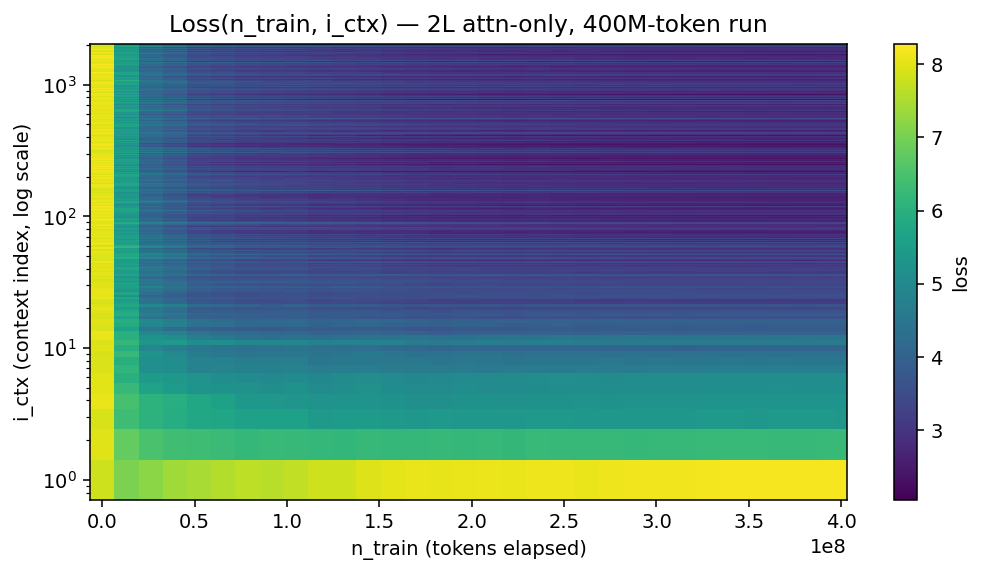

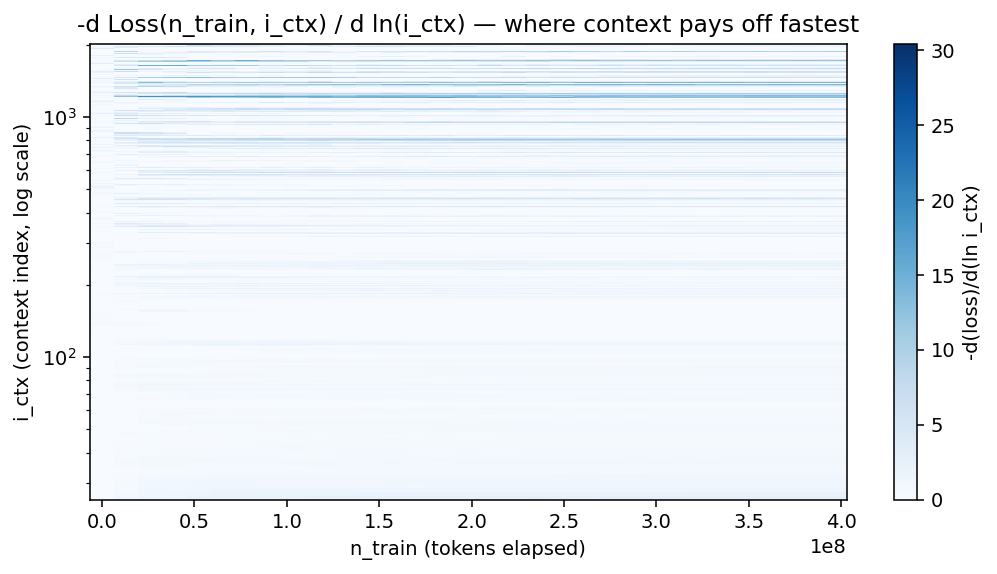

In [20]:
import matplotlib.pyplot as plt


def smooth(row, w=51):
    row = np.asarray(row, dtype=float)
    return np.convolve(row, np.ones(w) / w, mode="same")


def log_edges(centers):
    # pcolormesh's shading="auto" interpolates edges *linearly* between given centers, which is
    # wrong once the axis is displayed on a log scale (our steps are ~evenly spaced in linear
    # token-count, wildly uneven in log-space) -- it silently produced a garbage autoscaled xlim.
    # Computing edges as the log-space midpoint between neighbors fixes it.
    lc = np.log10(centers)
    mid = (lc[:-1] + lc[1:]) / 2
    first = lc[0] - (mid[0] - lc[0])
    last = lc[-1] + (lc[-1] - mid[-1])
    return 10 ** np.concatenate([[first], mid, [last]])


def linear_edges(centers):
    # same idea as log_edges, but for an axis displayed on a linear scale -- plain arithmetic
    # midpoints between neighboring centers, not log-space ones.
    centers = np.asarray(centers, dtype=float)
    mid = (centers[:-1] + centers[1:]) / 2
    first = centers[0] - (mid[0] - centers[0])
    last = centers[-1] + (centers[-1] - mid[-1])
    return np.concatenate([[first], mid, [last]])


Z = np.array(per_pos)  # (n_logged_steps, n_ctx - 1)
i_ctx = np.arange(1, Z.shape[1] + 1)  # 1-indexed context position
tokens_per_step = BATCH_SIZE * n_ctx
n_train = np.array(steps) * tokens_per_step  # linear x-axis now, so step 0 -> n_train=0 is fine
x_edges = linear_edges(n_train)
y_edges = log_edges(i_ctx)

fig, ax = plt.subplots(figsize=(7.6, 4.2), dpi=140)
mesh = ax.pcolormesh(x_edges, y_edges, Z.T, shading="flat", cmap="viridis")
ax.set_yscale("log")
ax.set_xlabel("n_train (tokens elapsed)")
ax.set_ylabel("i_ctx (context index, log scale)")
ax.set_title("Loss(n_train, i_ctx) — 2L attn-only, 400M-token run")
fig.colorbar(mesh, ax=ax, label="loss")
fig.tight_layout()
plt.show()

# np.convolve(..., mode="same") zero-pads outside the row, biasing the smoothed value near each
# edge toward zero -- differentiating then produces a spurious, huge gradient right at the
# boundary (observed: ~300+ vs. a clean ~30 in the interior). Trim the half-window on both sides
# before differentiating instead of just clipping the color scale over it.
w = 51
half = w // 2
smoothed = np.stack([smooth(row, w) for row in Z])[:, half:-half]
i_ctx_trim = i_ctx[half:-half]
log_ctx_trim = np.log(i_ctx_trim)
D = np.gradient(smoothed, log_ctx_trim, axis=1)  # (n_logged_steps, n_ctx - 1 - 2*half)
context_payoff = -D  # positive where more context is reducing loss (the typical case)
y_edges_trim = log_edges(i_ctx_trim)

fig, ax = plt.subplots(figsize=(7.6, 4.2), dpi=140)
mesh = ax.pcolormesh(x_edges, y_edges_trim, context_payoff.T, shading="flat", cmap="Blues", vmin=0)
ax.set_yscale("log")
ax.set_xlabel("n_train (tokens elapsed)")
ax.set_ylabel("i_ctx (context index, log scale)")
ax.set_title("-d Loss(n_train, i_ctx) / d ln(i_ctx) — where context pays off fastest")
fig.colorbar(mesh, ax=ax, label="-d(loss)/d(ln i_ctx)")
fig.tight_layout()
plt.show()

## Depth/MLP sweep — same plots, four new architectures

`train_depth_sweep.py` (run overnight, offline — see that file's docstring for why it's a
standalone script rather than more notebook cells) trained three additional attention-only depths
(2, 3, 6 layers — the 2-layer one is a fresh, independent run of this same architecture, not a
duplicate of the main run above) plus a 2-layer **with MLPs** variant, all on the same corpus and
tokenizer, all using a log-spaced early-eval schedule instead of the uniform `EVAL_EVERY=100` above
— fixing the resolution gap the paper-style plots and heatmaps exposed earlier (44 of ~57-66
logged points now land below step 1000, instead of just 2).

Same three plot types as above, reproduced for all four configs at once for direct comparison, each
annotated with that config's own phase-transition window (shaded band = 10-90% crossing, dashed
line = halfway crossing) — computed the same way as the main run, independently per config.

In [21]:
SWEEP_DIR = "checkpoints/icl_depth_sweep"
SWEEP_CONFIGS = [
    ("L2_attn", "2L attn-only"),
    ("L3_attn", "3L attn-only"),
    ("L6_attn", "6L attn-only"),
    ("L2_mlp", "2L + MLP"),
]


def window_icl_generic(rows, w=25, a=49, b=499):
    out = []
    for row in rows:
        win_b = sum(row[b - w : b + w]) / (2 * w)
        win_a = sum(row[a - w : a + w]) / (2 * w)
        out.append(win_b - win_a)
    return out


def interp_crossing_generic(icl, steps_, target_frac):
    floor_, plateau_ = icl[0], icl[-1]
    frac = [(v - floor_) / (plateau_ - floor_) for v in icl]
    for i in range(1, len(frac)):
        if frac[i] >= target_frac:
            f0, f1 = frac[i - 1], frac[i]
            t = (target_frac - f0) / (f1 - f0) if f1 != f0 else 0
            return steps_[i - 1] + t * (steps_[i] - steps_[i - 1])
    return steps_[-1]


sweep_data = {}
for label, title in SWEEP_CONFIGS:
    with open(f"{SWEEP_DIR}/{label}/metrics.json") as f:
        m = json.load(f)
    steps_s = m["steps"]
    icl_s = window_icl_generic(m["per_position_loss"])
    sweep_data[label] = dict(
        title=title,
        steps=steps_s,
        eval_loss=m["eval_loss"],
        per_pos=m["per_position_loss"],
        icl=icl_s,
        window_start=interp_crossing_generic(icl_s, steps_s, 0.1),
        window_end=interp_crossing_generic(icl_s, steps_s, 0.9),
        half_step=interp_crossing_generic(icl_s, steps_s, 0.5),
        batch=m["batch_size"],
    )
    print(
        f"[{label}] {len(steps_s)} points, max_step={steps_s[-1]}, "
        f"ICL {icl_s[0]:.3f} -> {icl_s[-1]:.3f}, halfway ~step {sweep_data[label]['half_step']:.0f}"
    )

[L2_attn] 66 points, max_step=3050, ICL 0.064 -> -0.361, halfway ~step 114
[L3_attn] 66 points, max_step=3050, ICL -0.022 -> -0.401, halfway ~step 196
[L6_attn] 57 points, max_step=2164, ICL -0.019 -> -0.399, halfway ~step 187
[L2_mlp] 66 points, max_step=3050, ICL 0.037 -> -0.194, halfway ~step 63


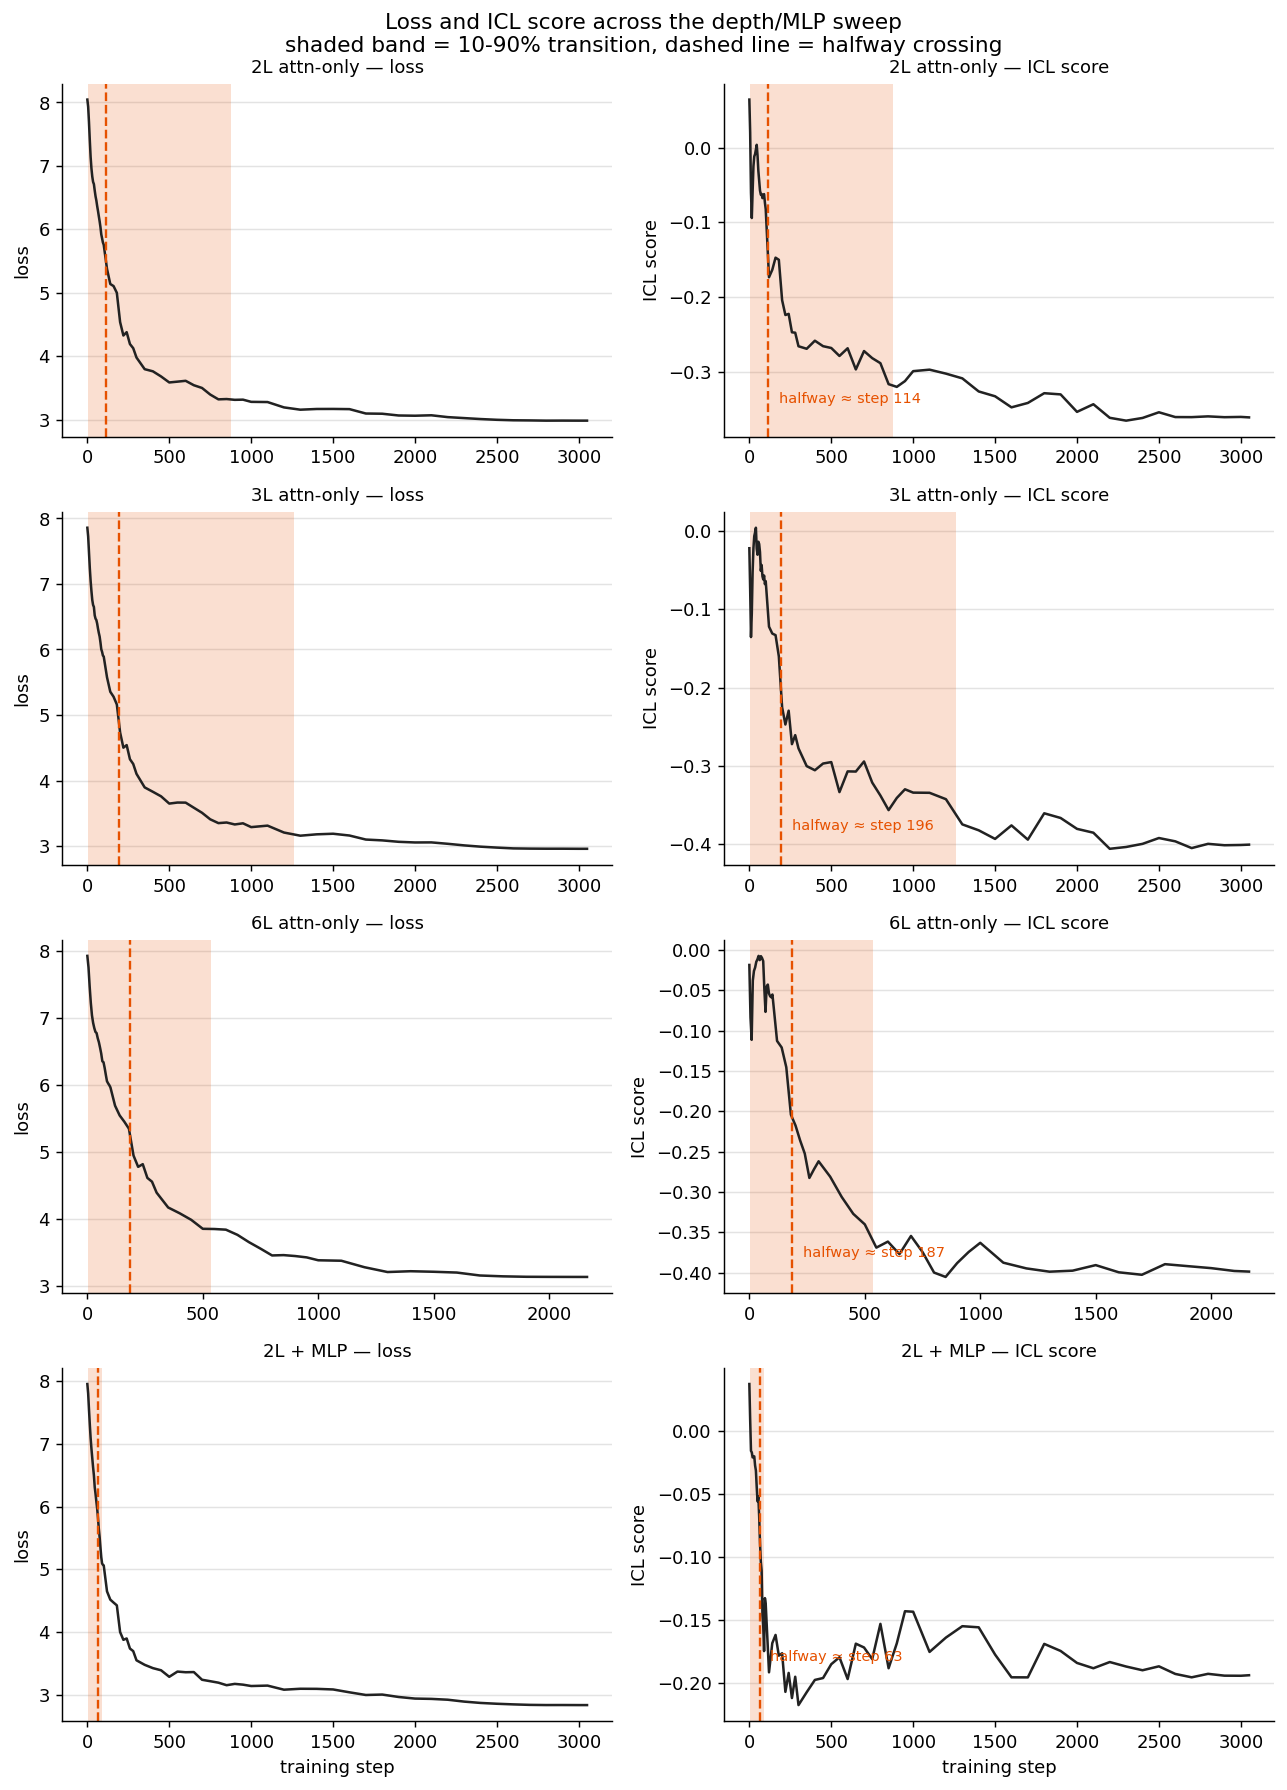

In [22]:
fig, axes = plt.subplots(4, 2, figsize=(10, 14), dpi=130)

for row_i, (label, _) in enumerate(SWEEP_CONFIGS):
    d = sweep_data[label]
    ax_loss, ax_icl = axes[row_i]
    for ax, y, ylabel in [(ax_loss, d["eval_loss"], "loss"), (ax_icl, d["icl"], "ICL score")]:
        ax.plot(d["steps"], y, color="#222222", linewidth=1.4)
        ax.axvspan(d["window_start"], d["window_end"], color=HIGHLIGHT, alpha=0.18, linewidth=0)
        ax.axvline(d["half_step"], color=HIGHLIGHT, linestyle="--", linewidth=1.3)
        ax.set_ylabel(ylabel)
        ax.grid(True, axis="y", color="#e3e3e3", linewidth=0.8, zorder=0)
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
    ax_loss.set_title(f"{d['title']} — loss", fontsize=10)
    ax_icl.set_title(f"{d['title']} — ICL score", fontsize=10)
    ax_icl.annotate(
        f"halfway ≈ step {d['half_step']:.0f}",
        xy=(d["half_step"], d["icl"][-1]),
        xytext=(6, 8),
        textcoords="offset points",
        color=HIGHLIGHT,
        fontsize=8,
    )
    if row_i == 3:
        ax_loss.set_xlabel("training step")
        ax_icl.set_xlabel("training step")

fig.suptitle(
    "Loss and ICL score across the depth/MLP sweep\nshaded band = 10-90% transition, dashed line = halfway crossing",
    fontsize=12,
)
fig.tight_layout()
plt.show()

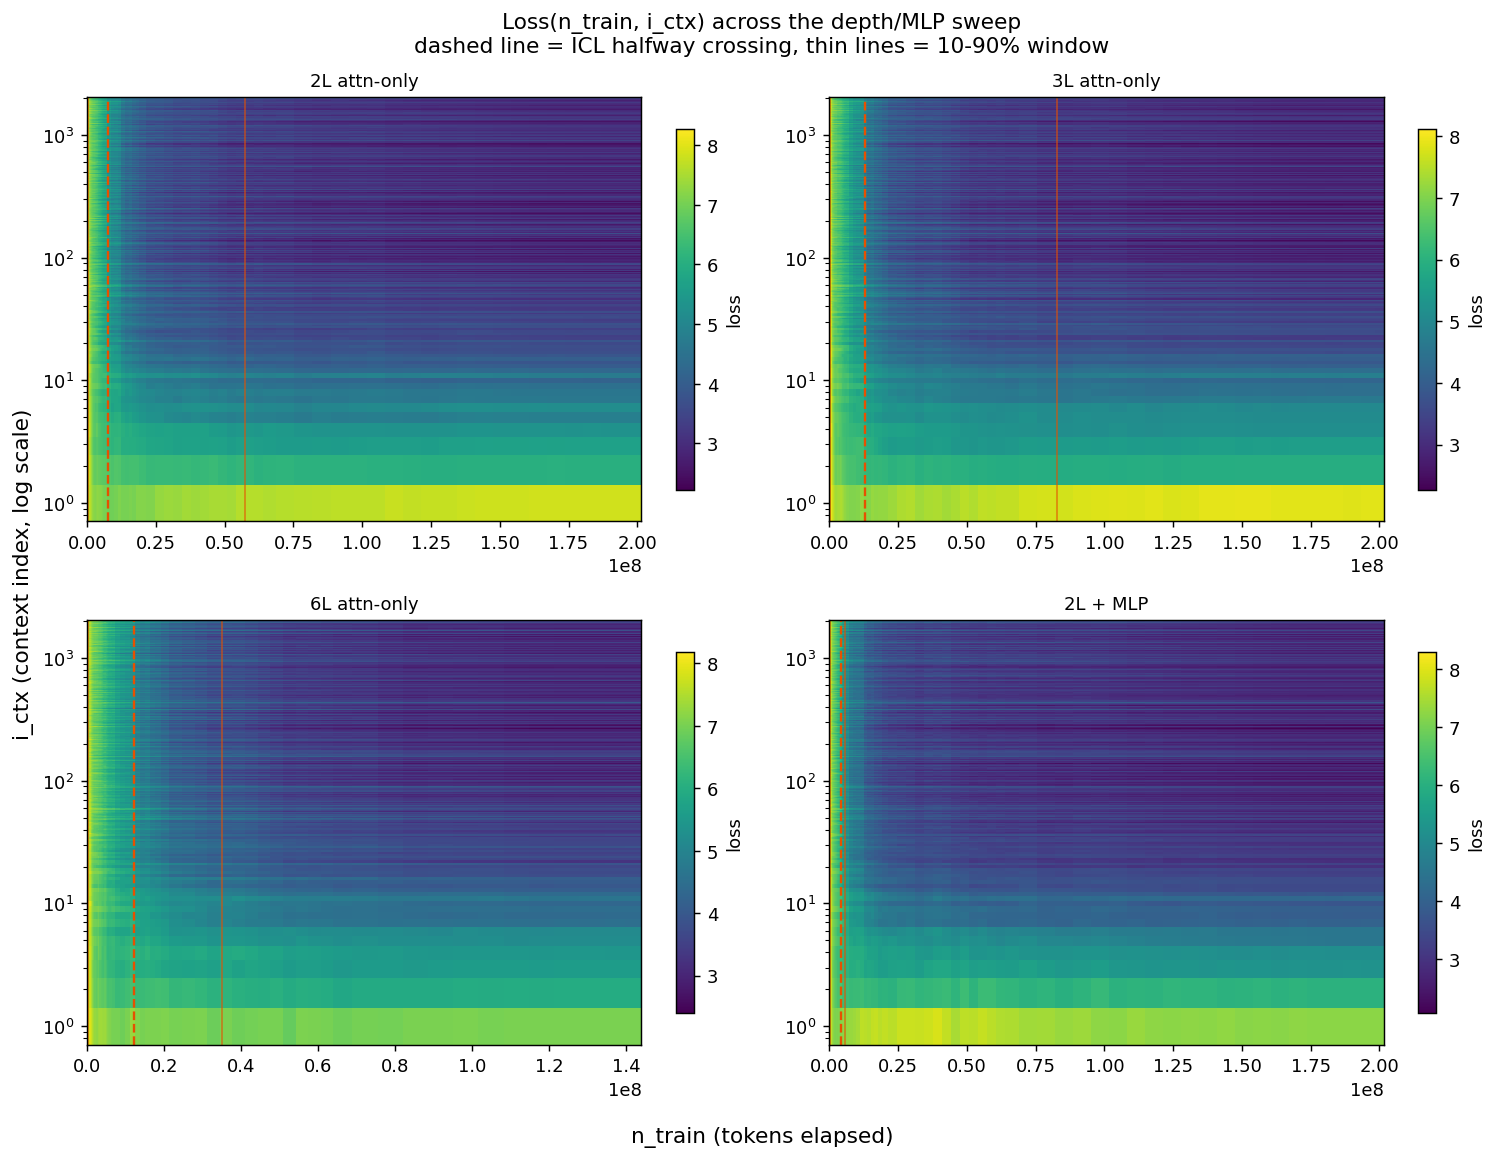

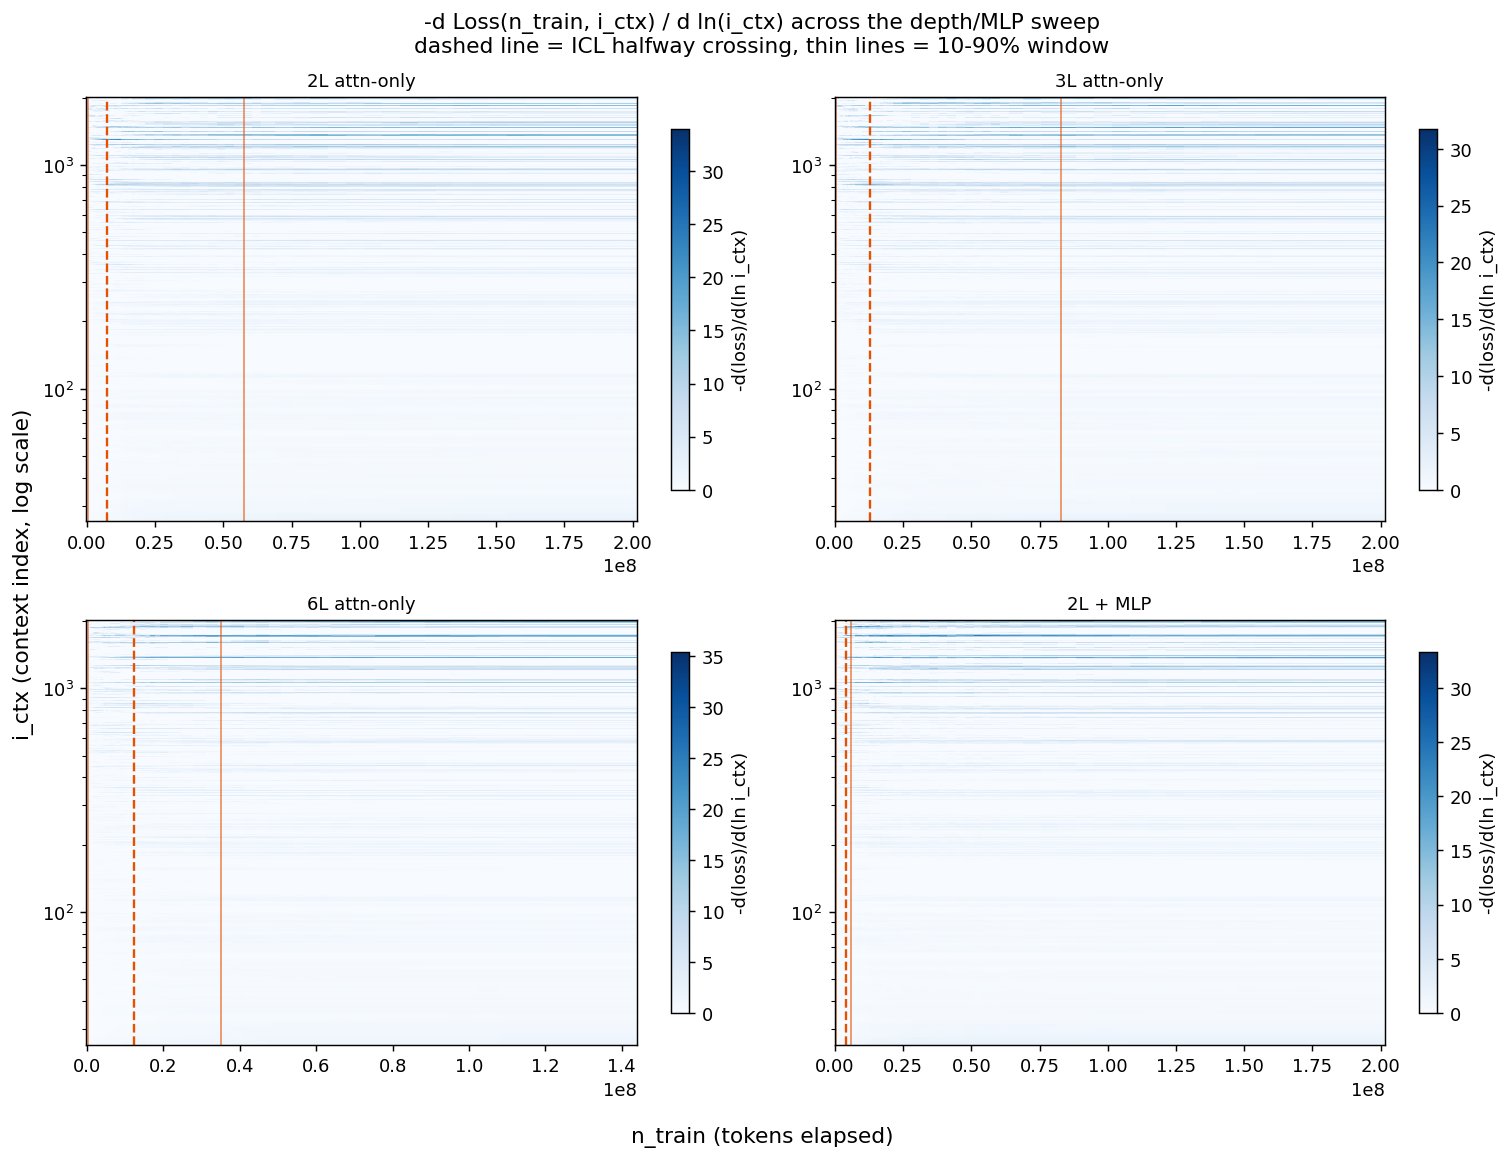

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), dpi=130)

for ax, (label, _) in zip(axes.flat, SWEEP_CONFIGS):
    d = sweep_data[label]
    Z = np.array(d["per_pos"])
    i_ctx = np.arange(1, Z.shape[1] + 1)
    tokens_per_step = d["batch"] * n_ctx
    n_train = np.array(d["steps"]) * tokens_per_step
    x_edges = linear_edges(n_train)
    y_edges = log_edges(i_ctx)

    mesh = ax.pcolormesh(x_edges, y_edges, Z.T, shading="flat", cmap="viridis")
    ax.set_yscale("log")
    ax.set_title(d["title"], fontsize=10)
    for s in (d["window_start"], d["window_end"]):
        ax.axvline(s * tokens_per_step, color=HIGHLIGHT, alpha=0.6, linewidth=1)
    ax.axvline(d["half_step"] * tokens_per_step, color=HIGHLIGHT, linestyle="--", linewidth=1.3)
    fig.colorbar(mesh, ax=ax, label="loss", shrink=0.85)

fig.supxlabel("n_train (tokens elapsed)")
fig.supylabel("i_ctx (context index, log scale)")
fig.suptitle(
    "Loss(n_train, i_ctx) across the depth/MLP sweep\ndashed line = ICL halfway crossing, thin lines = 10-90% window",
    fontsize=12,
)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 9), dpi=130)
w, half = 51, 51 // 2

for ax, (label, _) in zip(axes.flat, SWEEP_CONFIGS):
    d = sweep_data[label]
    Z = np.array(d["per_pos"])
    i_ctx = np.arange(1, Z.shape[1] + 1)
    tokens_per_step = d["batch"] * n_ctx
    n_train = np.array(d["steps"]) * tokens_per_step
    x_edges = linear_edges(n_train)

    smoothed = np.stack([smooth(row, w) for row in Z])[:, half:-half]
    i_ctx_trim = i_ctx[half:-half]
    log_ctx_trim = np.log(i_ctx_trim)
    D = np.gradient(smoothed, log_ctx_trim, axis=1)
    context_payoff = -D
    y_edges_trim = log_edges(i_ctx_trim)

    mesh = ax.pcolormesh(x_edges, y_edges_trim, context_payoff.T, shading="flat", cmap="Blues", vmin=0)
    ax.set_yscale("log")
    ax.set_title(d["title"], fontsize=10)
    for s in (d["window_start"], d["window_end"]):
        ax.axvline(s * tokens_per_step, color=HIGHLIGHT, alpha=0.6, linewidth=1)
    ax.axvline(d["half_step"] * tokens_per_step, color=HIGHLIGHT, linestyle="--", linewidth=1.3)
    fig.colorbar(mesh, ax=ax, label="-d(loss)/d(ln i_ctx)", shrink=0.85)

fig.supxlabel("n_train (tokens elapsed)")
fig.supylabel("i_ctx (context index, log scale)")
fig.suptitle(
    "-d Loss(n_train, i_ctx) / d ln(i_ctx) across the depth/MLP sweep\n"
    "dashed line = ICL halfway crossing, thin lines = 10-90% window",
    fontsize=12,
)
fig.tight_layout()
plt.show()